In [57]:
import matplotlib.pyplot as plt
import numpy as np
from create_data import generate_demand, generate_links, generate_nodes
from helpers import FW, compute_travel_times
from plots import plot_network
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
np.set_printoptions(precision=2, suppress=True)

# Creation of network

In [15]:
X = 25
Y = 18
idx_doors = [74, 429, 445]
speed_flat = 1.25
speef_stairs = 0.7
speed_chairs = 1
grid_size = 1   # [m]

In [16]:
df_nodes = generate_nodes(X, Y, idx_doors)
df_nodes

,node_id,x_coord,y_coord,links_out,capacity
0,0,0,0,"[0, 1]",4.0
1,1,1,0,"[2, 3, 4]",4.0
2,2,2,0,"[5, 6, 7]",4.0
3,3,3,0,"[8, 9, 10]",4.0
4,4,4,0,"[11, 12, 13]",4.0
...,...,...,...,...,...
445,445,20,17,[],inf
446,446,21,17,"[1276, 1277, 1278]",4.0
447,447,22,17,"[1279, 1280, 1281]",4.0
448,448,23,17,"[1282, 1283, 1284]",4.0


In [17]:
df_links = generate_links(df_nodes, speed_flat, speef_stairs, speed_chairs, grid_size, idx_doors)
df_links

,link_id,start_node,end_node,t0,sat
0,0,0,1,0.8,4
1,1,0,25,0.8,4
2,2,1,0,0.8,4
3,3,1,2,0.8,4
4,4,1,26,0.8,4
...,...,...,...,...,...
1282,1282,448,447,0.8,4
1283,1283,448,449,0.8,4
1284,1284,448,423,0.8,4
1285,1285,449,448,0.8,4


In [18]:
week = 14
df_od, people_seat = generate_demand(df_nodes, week, type_dystrib='even')
df_od

,od_id,origin,destination,demand
0,0,151,74,1.0
1,1,153,445,1.0
2,2,154,445,1.0
3,3,155,429,1.0
4,4,159,429,1.0
...,...,...,...,...
71,71,384,74,1.0
72,72,388,445,1.0
73,73,391,429,1.0
74,74,395,74,1.0


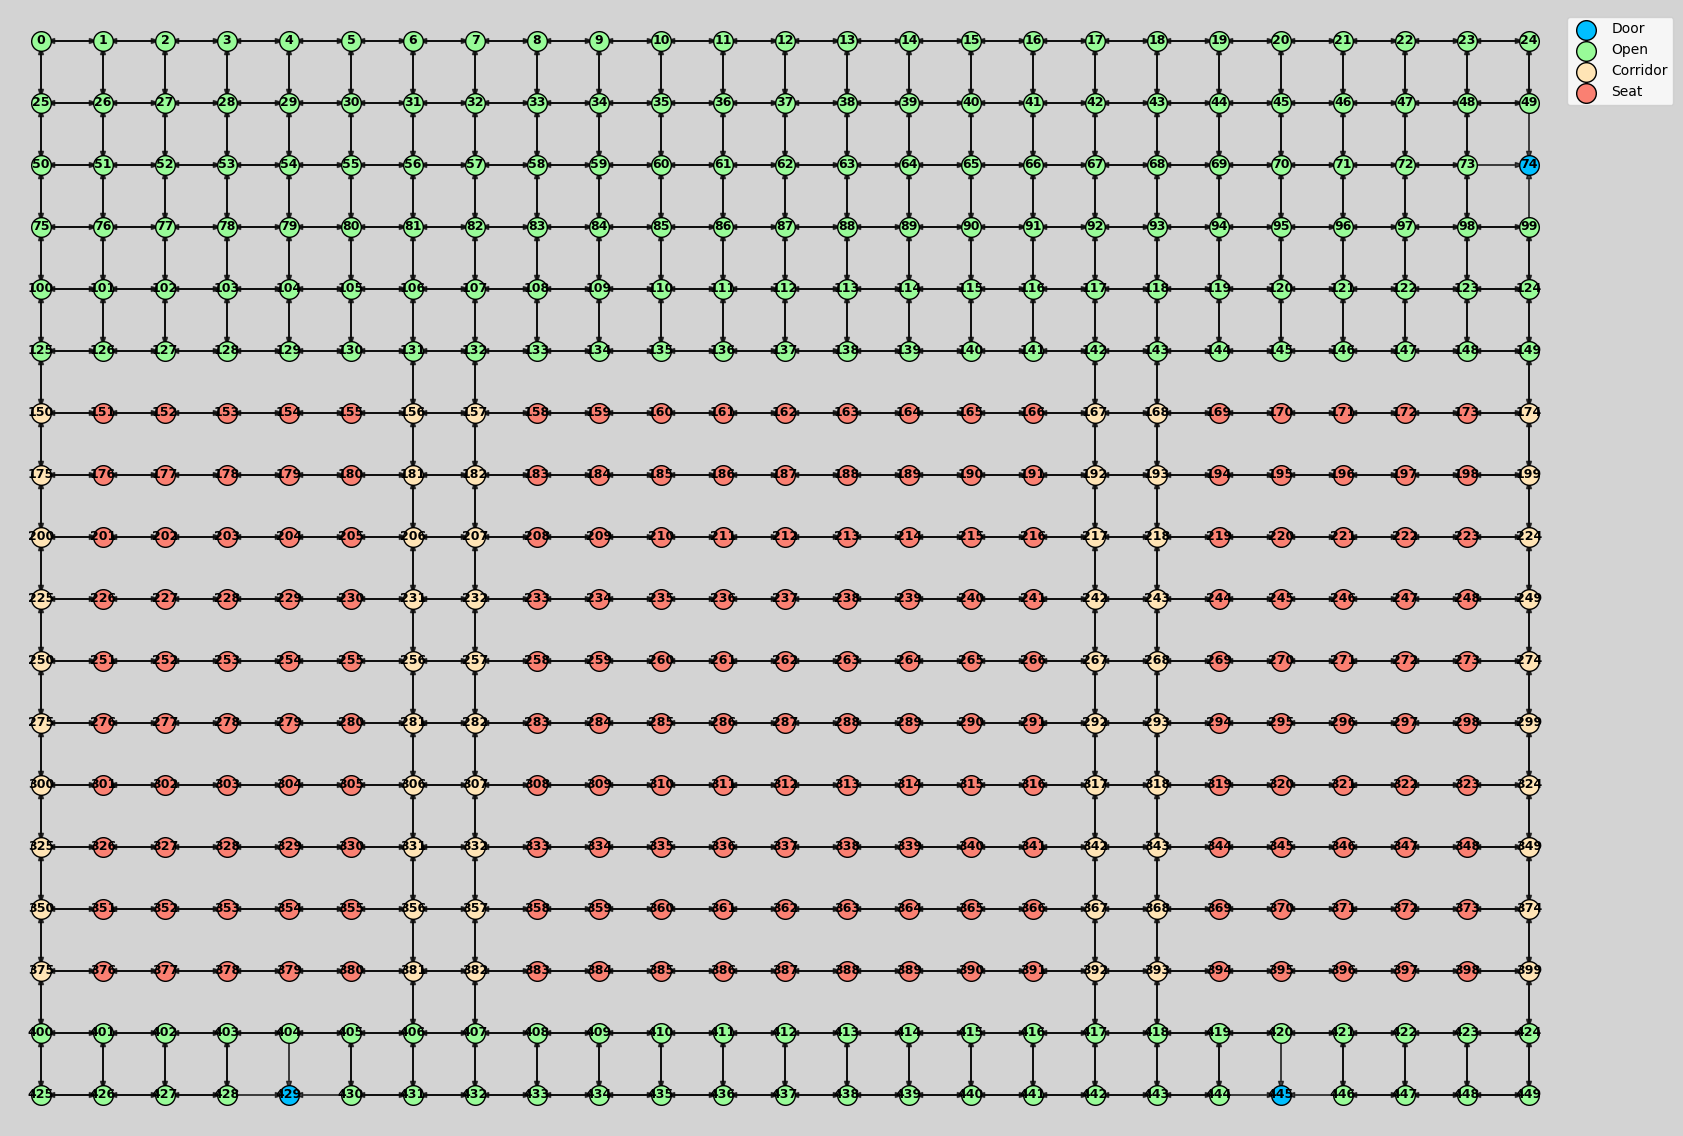

In [19]:
plot_network(df_nodes, df_links, idx_doors, X, Y, True, False, figsize=(20,20), name="image/CE1.pdf")

# Solving algorithms

In [20]:
def BPR(x, t0, c, alpha, beta):
    """
    BPR function of travel time

    :param x: current link flow
    :param t0: free flow travel time
    :param c: link capacity
    :param alpha: scale parameter
    :param beta: shape parameter

    :return t: travel time per link
    """
    ratio = x / c
    demand_factor = 1 + alpha * np.pow(ratio, beta)
    t = t0 * demand_factor
    return t

In [21]:
def barrier(x, c):
    """
    Barrier function of travel time for capacity

    :param x: current link flow
    :param t0: free flow travel time

    :return b: barrier value per link
    """

    b = np.zeros(x.shape[0])
    mask = x <= c
    b[~mask] = 100000
    return b

### User equilibrium

In [22]:
def link_cost_function_ue(x, alpha, beta, df_links):
    t0 = df_links["t0"].to_numpy()
    c = df_links["sat"].to_numpy()

    t_bpr = BPR(x, t0, c, alpha, beta)
    b = barrier(x,c)
    t = t_bpr + b
    return t

def objective_function_ue(x, alpha, beta, df_links):
    t0 = df_links["t0"].to_numpy()
    c = df_links["sat"].to_numpy()

    integ_t = t0 * (x + (alpha / (beta+1)) * ( np.pow(x,beta+1) / np.pow(c,beta)))
    obj = np.sum(integ_t)
    return obj

In [39]:
max_iter = 5000
max_gap = 1e-4
max_gap_ls = 1e-2
link_cost_function = link_cost_function_ue
objective_function = objective_function_ue
alpha = 0.15
beta = 4

x_star_ue, gap_ue, obj_ue = FW(max_iter, max_gap, max_gap_ls, link_cost_function, objective_function, df_od, df_links, df_nodes, alpha, beta)

Iteration : 500 / 5000
Iteration : 1000 / 5000
Iteration : 1500 / 5000
Iteration : 2000 / 5000
Iteration : 2500 / 5000
Iteration : 3000 / 5000
Iteration : 3500 / 5000
Iteration : 4000 / 5000
Iteration : 4500 / 5000
Iteration : 5000 / 5000


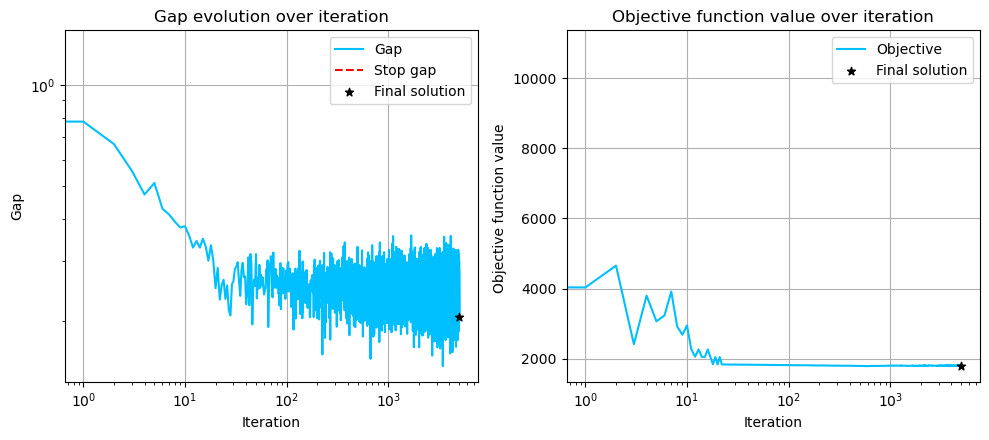

In [40]:
plt.figure(figsize=(10,4.5))

plt.subplot(1,2,1)
plt.loglog(np.arange(len(gap_ue)), gap_ue, color='Deepskyblue', label='Gap')
plt.hlines(1e-4, 0, 2*max_iter, color='red', linestyles='--', label='Stop gap')
plt.scatter(len(gap_ue)-1, gap_ue[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Gap")
plt.title("Gap evolution over iteration")

plt.legend()

plt.subplot(1,2,2)
plt.semilogx(np.arange(len(obj_ue)), obj_ue, color='Deepskyblue', label='Objective')
plt.scatter(len(obj_ue)-1, obj_ue[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Objective function value ")
plt.title("Objective function value over iteration")
plt.legend()

plt.tight_layout()
plt.show()

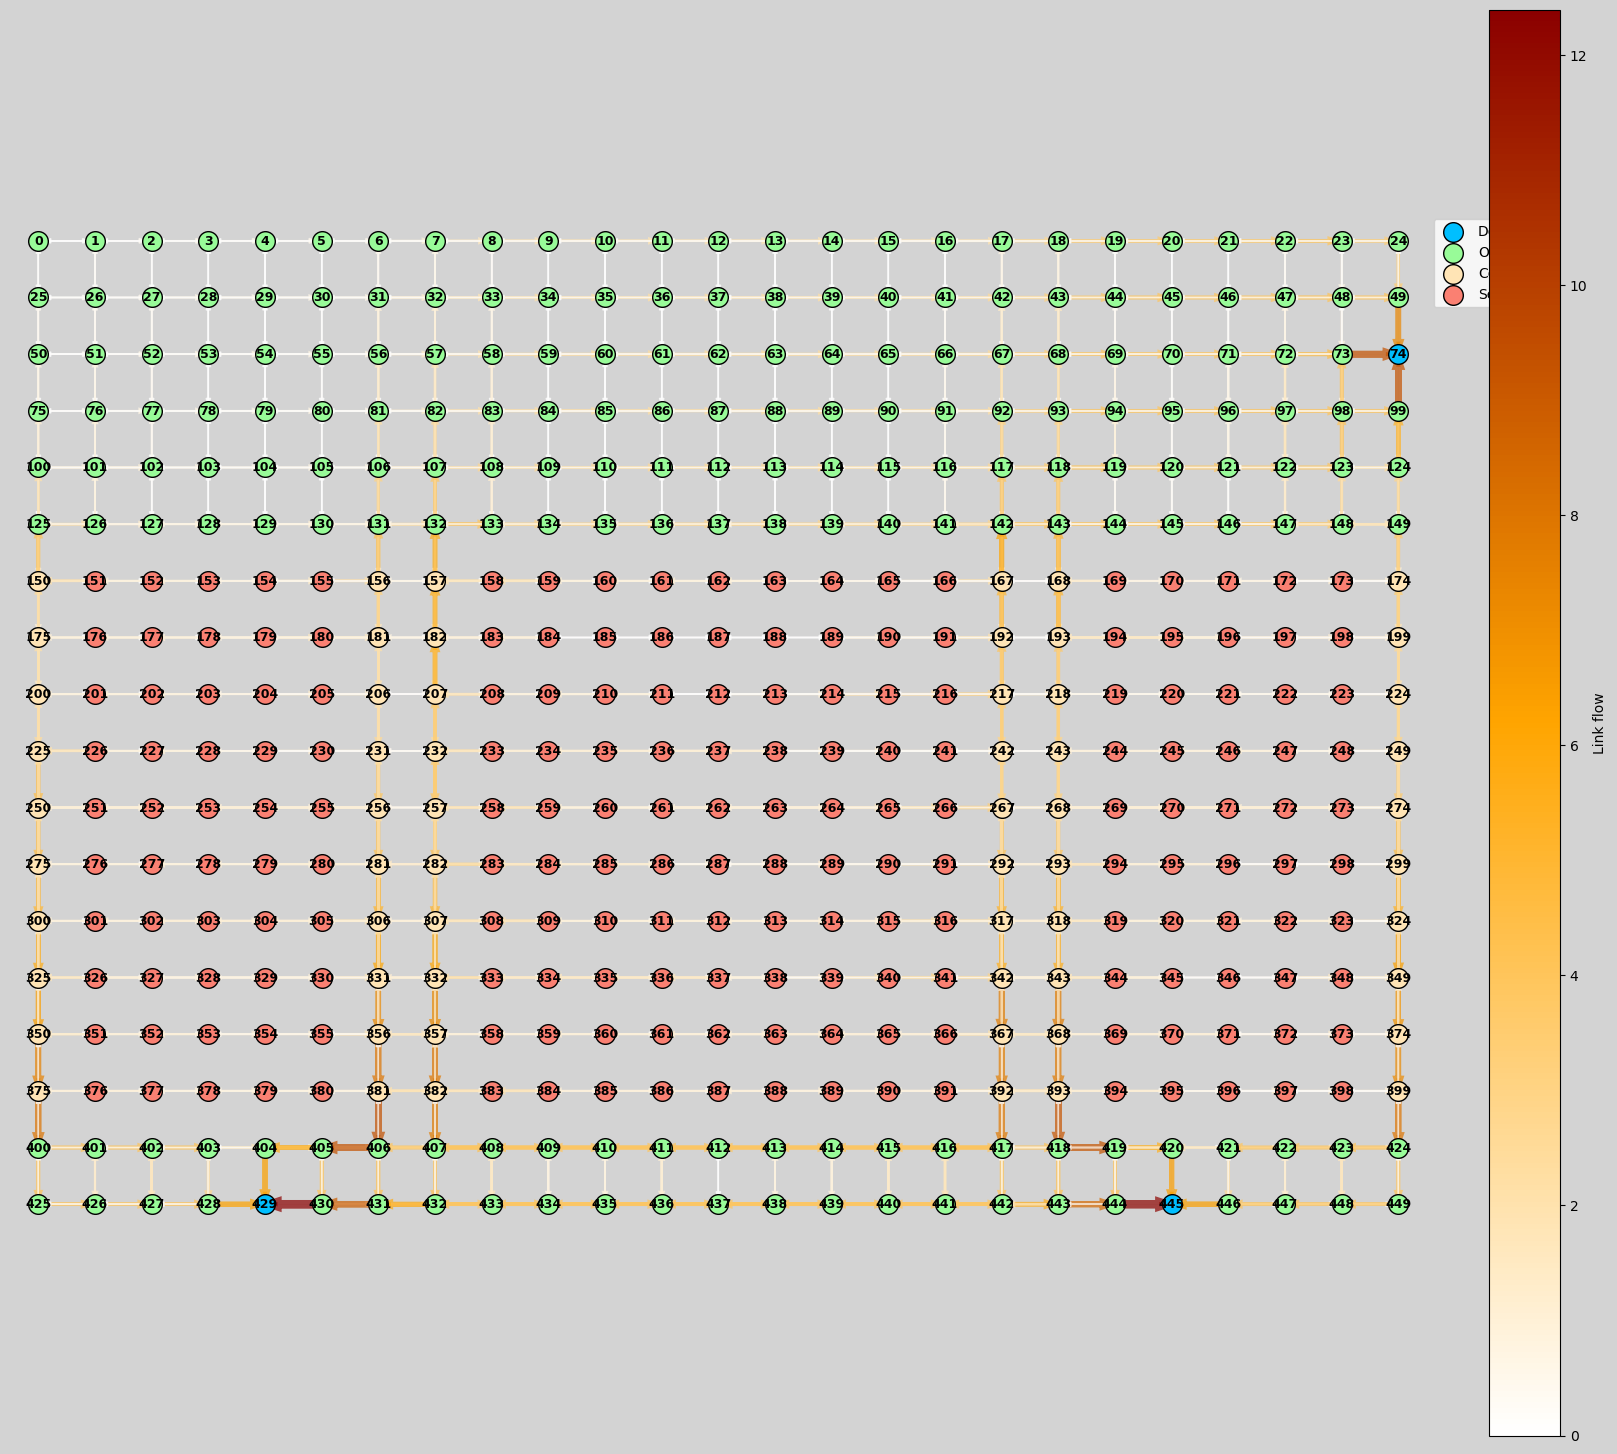

In [25]:
plot_network(df_nodes, df_links, idx_doors, X, Y, True, False, figsize=(20,20), x=x_star_ue, name="image/CE1_UE.pdf")

### System optimum

In [26]:
def link_cost_function_so(x, alpha, beta, df_links):
    t0 = df_links["t0"].to_numpy()
    c = df_links["sat"].to_numpy()

    t_bpr = BPR(x, t0, c, alpha, beta)
    tau = t0 * alpha * beta * ( np.pow(x, beta+1) / np.pow(c, beta) )
    b = barrier(x, c)
    t = t_bpr + x * tau + b
    return t

def objective_function_so(x, alpha, beta, df_links):
    t0 = df_links["t0"].to_numpy()
    c = df_links["sat"].to_numpy()

    obj = x @ BPR(x, t0, c, alpha, beta)
    return obj

In [62]:
max_iter = 5000
max_gap = 1e-4
max_gap_ls = 1e-2
link_cost_function = link_cost_function_so
objective_function = objective_function_so
alpha = 0.15
beta = 4

x_star_so, gap_so, obj_so = FW(max_iter, max_gap, max_gap_ls, link_cost_function, objective_function, df_od, df_links, df_nodes, alpha, beta)

Iteration : 500 / 5000
Iteration : 1000 / 5000
Iteration : 1500 / 5000
Iteration : 2000 / 5000
Iteration : 2500 / 5000
Iteration : 3000 / 5000
Iteration : 3500 / 5000
Iteration : 4000 / 5000
Iteration : 4500 / 5000
Iteration : 5000 / 5000


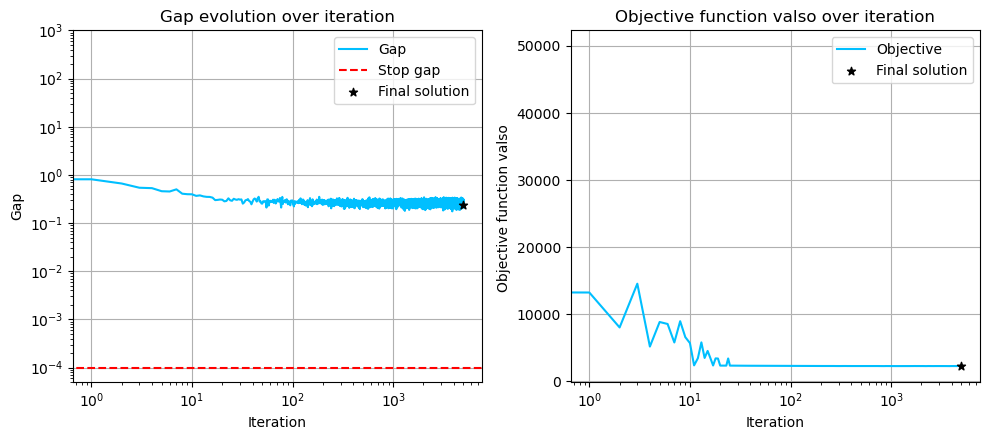

In [63]:
plt.figure(figsize=(10,4.5))

plt.subplot(1,2,1)
plt.loglog(np.arange(len(gap_so)), gap_so, color='Deepskyblue', label='Gap')
plt.hlines(1e-4, 0, 2*max_iter, color='red', linestyles='--', label='Stop gap')
plt.scatter(len(gap_so)-1, gap_so[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Gap")
plt.title("Gap evolution over iteration")
plt.ylim([5e-5, 1e3])
plt.legend()

plt.subplot(1,2,2)
plt.semilogx(np.arange(len(obj_so)), obj_so, color='Deepskyblue', label='Objective')
plt.scatter(len(obj_so)-1, obj_so[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Objective function valso ")
plt.title("Objective function valso over iteration")
plt.legend()

plt.tight_layout()
plt.show()

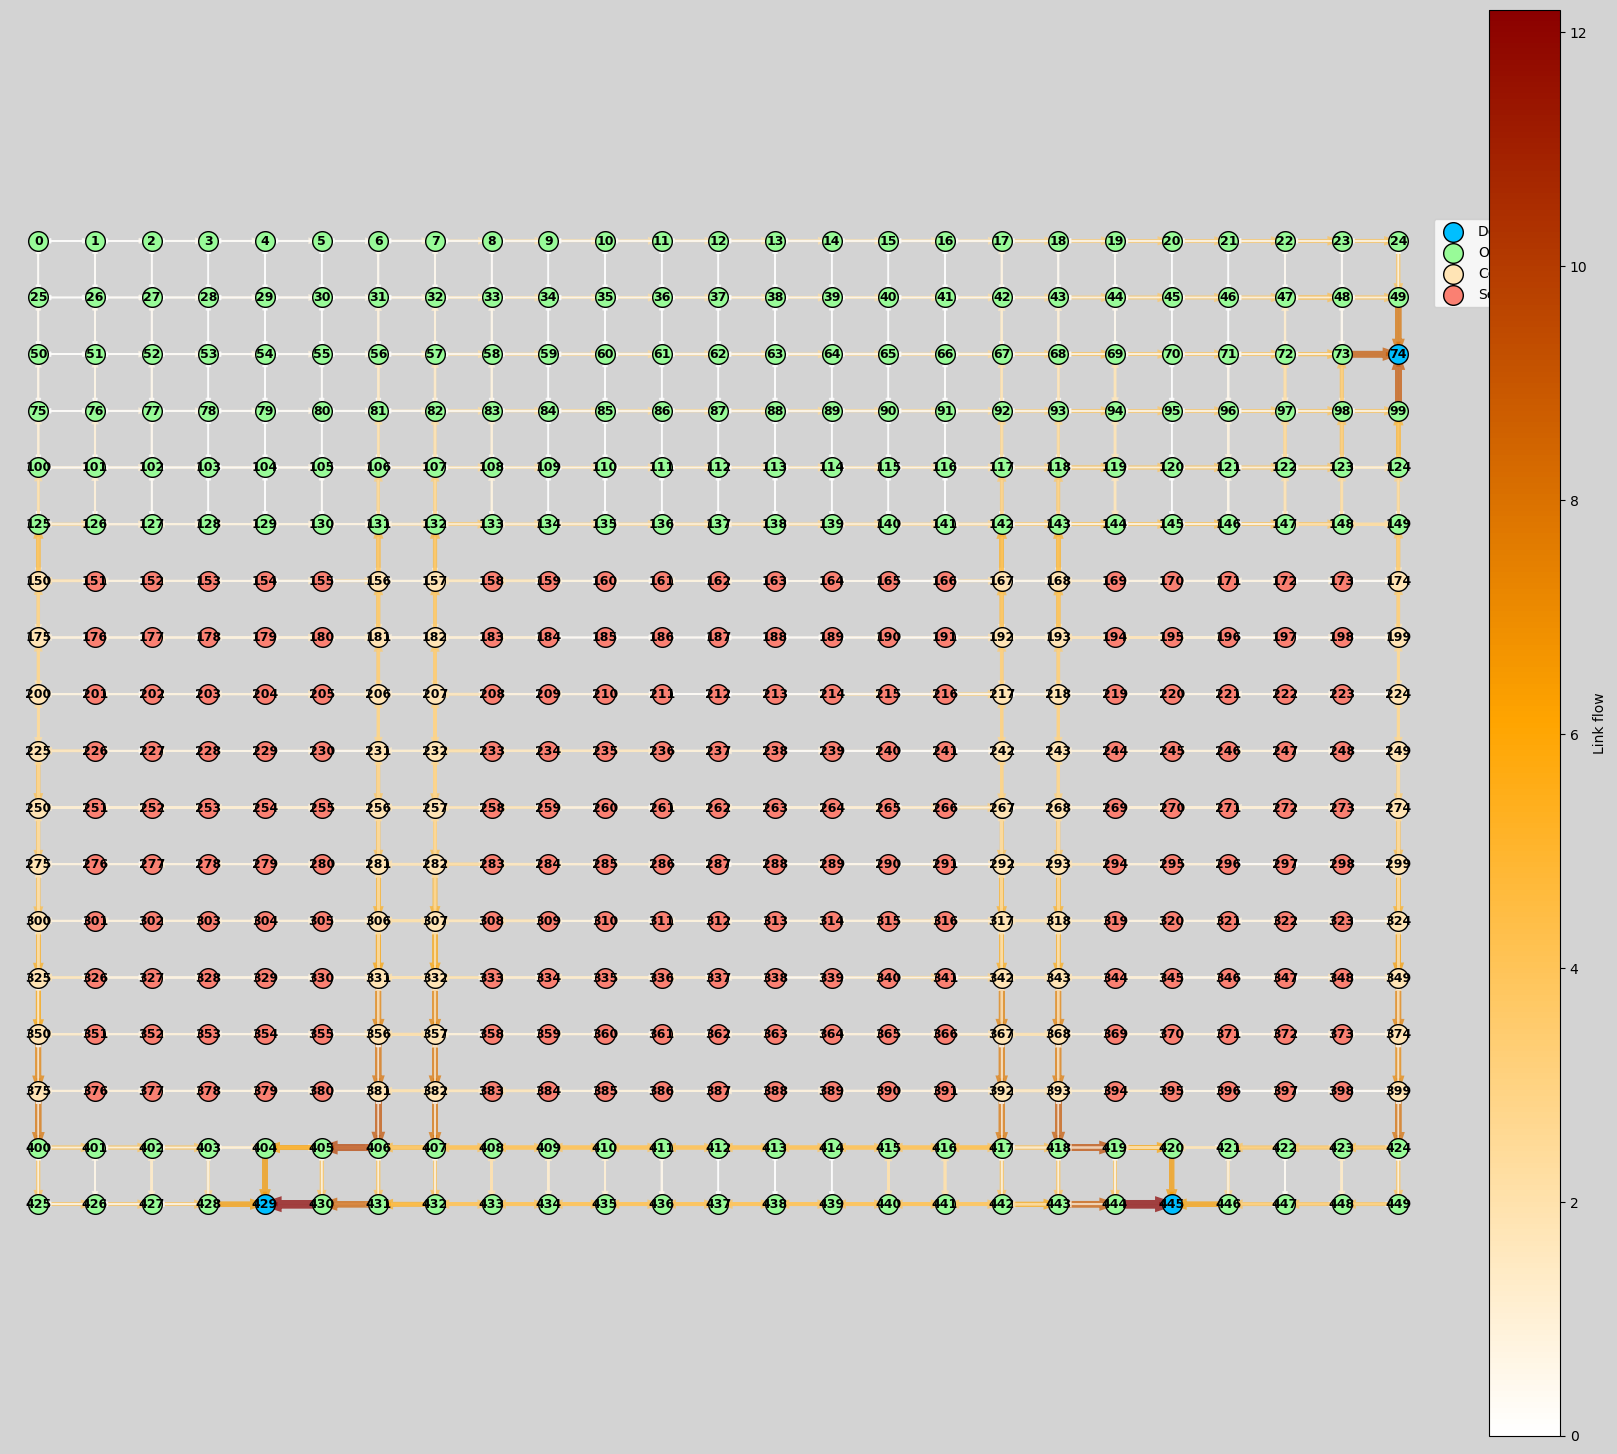

In [64]:
plot_network(df_nodes, df_links, idx_doors, X, Y, True, False, figsize=(20,20), x=x_star_so, name="image/CE1_SO.pdf")

### Price of anarchy "even"

In [65]:
tt_ue = objective_function_so(x=x_star_ue, alpha=alpha, beta=beta, df_links=df_links)
tt_so = objective_function_so(x=x_star_so, alpha=alpha, beta=beta, df_links=df_links)

print('total travel time at UE: {:0.2f}'.format(tt_ue))
print('total travel time at SO: {:0.2f}'.format(tt_so))
print('PoA: {:0.2f}'.format(tt_ue/tt_so))

total travel time at UE: 11552.94
total travel time at SO: 11431.23
PoA: 1.01


### Random demand generation

In [66]:
week = 14
df_od_rand, people_seat_rand = generate_demand(df_nodes, week, type_dystrib='random')
df_od_rand

,od_id,origin,destination,demand
0,0,151,74,1.0
1,1,152,445,1.0
2,2,153,429,1.0
3,3,161,74,1.0
4,4,162,74,1.0
...,...,...,...,...
71,71,387,429,1.0
72,72,388,429,1.0
73,73,389,445,1.0
74,74,391,74,1.0


#### User equilibrium "random"

In [67]:
max_iter = 5000
max_gap = 1e-4
max_gap_ls = 1e-2
link_cost_function = link_cost_function_ue
objective_function = objective_function_ue
alpha = 0.15
beta = 4

x_star_ue_rand, gap_ue_rand, obj_ue_rand = FW(max_iter, max_gap, max_gap_ls, link_cost_function, objective_function, df_od_rand, df_links, df_nodes, alpha, beta)

Iteration : 500 / 5000
Iteration : 1000 / 5000
Iteration : 1500 / 5000
Iteration : 2000 / 5000
Iteration : 2500 / 5000
Iteration : 3000 / 5000
Iteration : 3500 / 5000
Iteration : 4000 / 5000
Iteration : 4500 / 5000
Iteration : 5000 / 5000


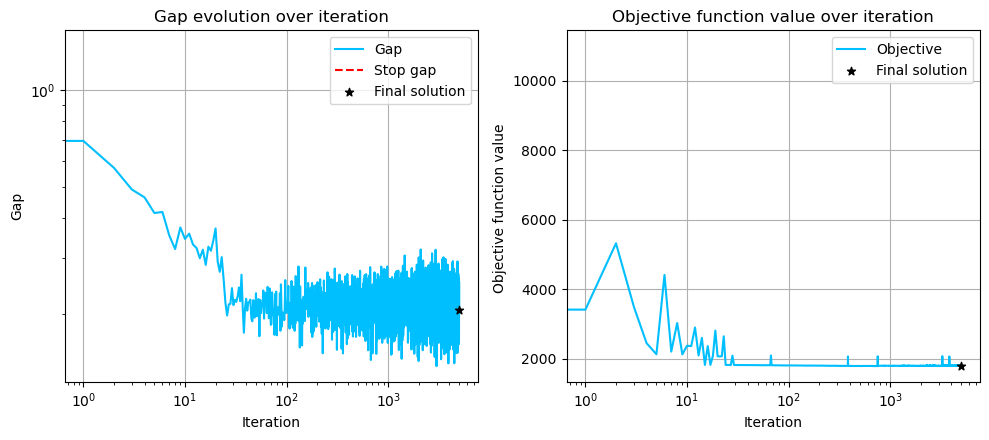

In [70]:
plt.figure(figsize=(10,4.5))

plt.subplot(1,2,1)
plt.loglog(np.arange(len(gap_ue_rand)), gap_ue_rand, color='Deepskyblue', label='Gap')
plt.hlines(1e-4, 0, 2*max_iter, color='red', linestyles='--', label='Stop gap')
plt.scatter(len(gap_ue_rand)-1, gap_ue_rand[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Gap")
plt.title("Gap evolution over iteration")

plt.legend()

plt.subplot(1,2,2)
plt.semilogx(np.arange(len(obj_ue_rand)), obj_ue_rand, color='Deepskyblue', label='Objective')
plt.scatter(len(obj_ue_rand)-1, obj_ue_rand[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Objective function value ")
plt.title("Objective function value over iteration")
plt.legend()

plt.tight_layout()
plt.show()

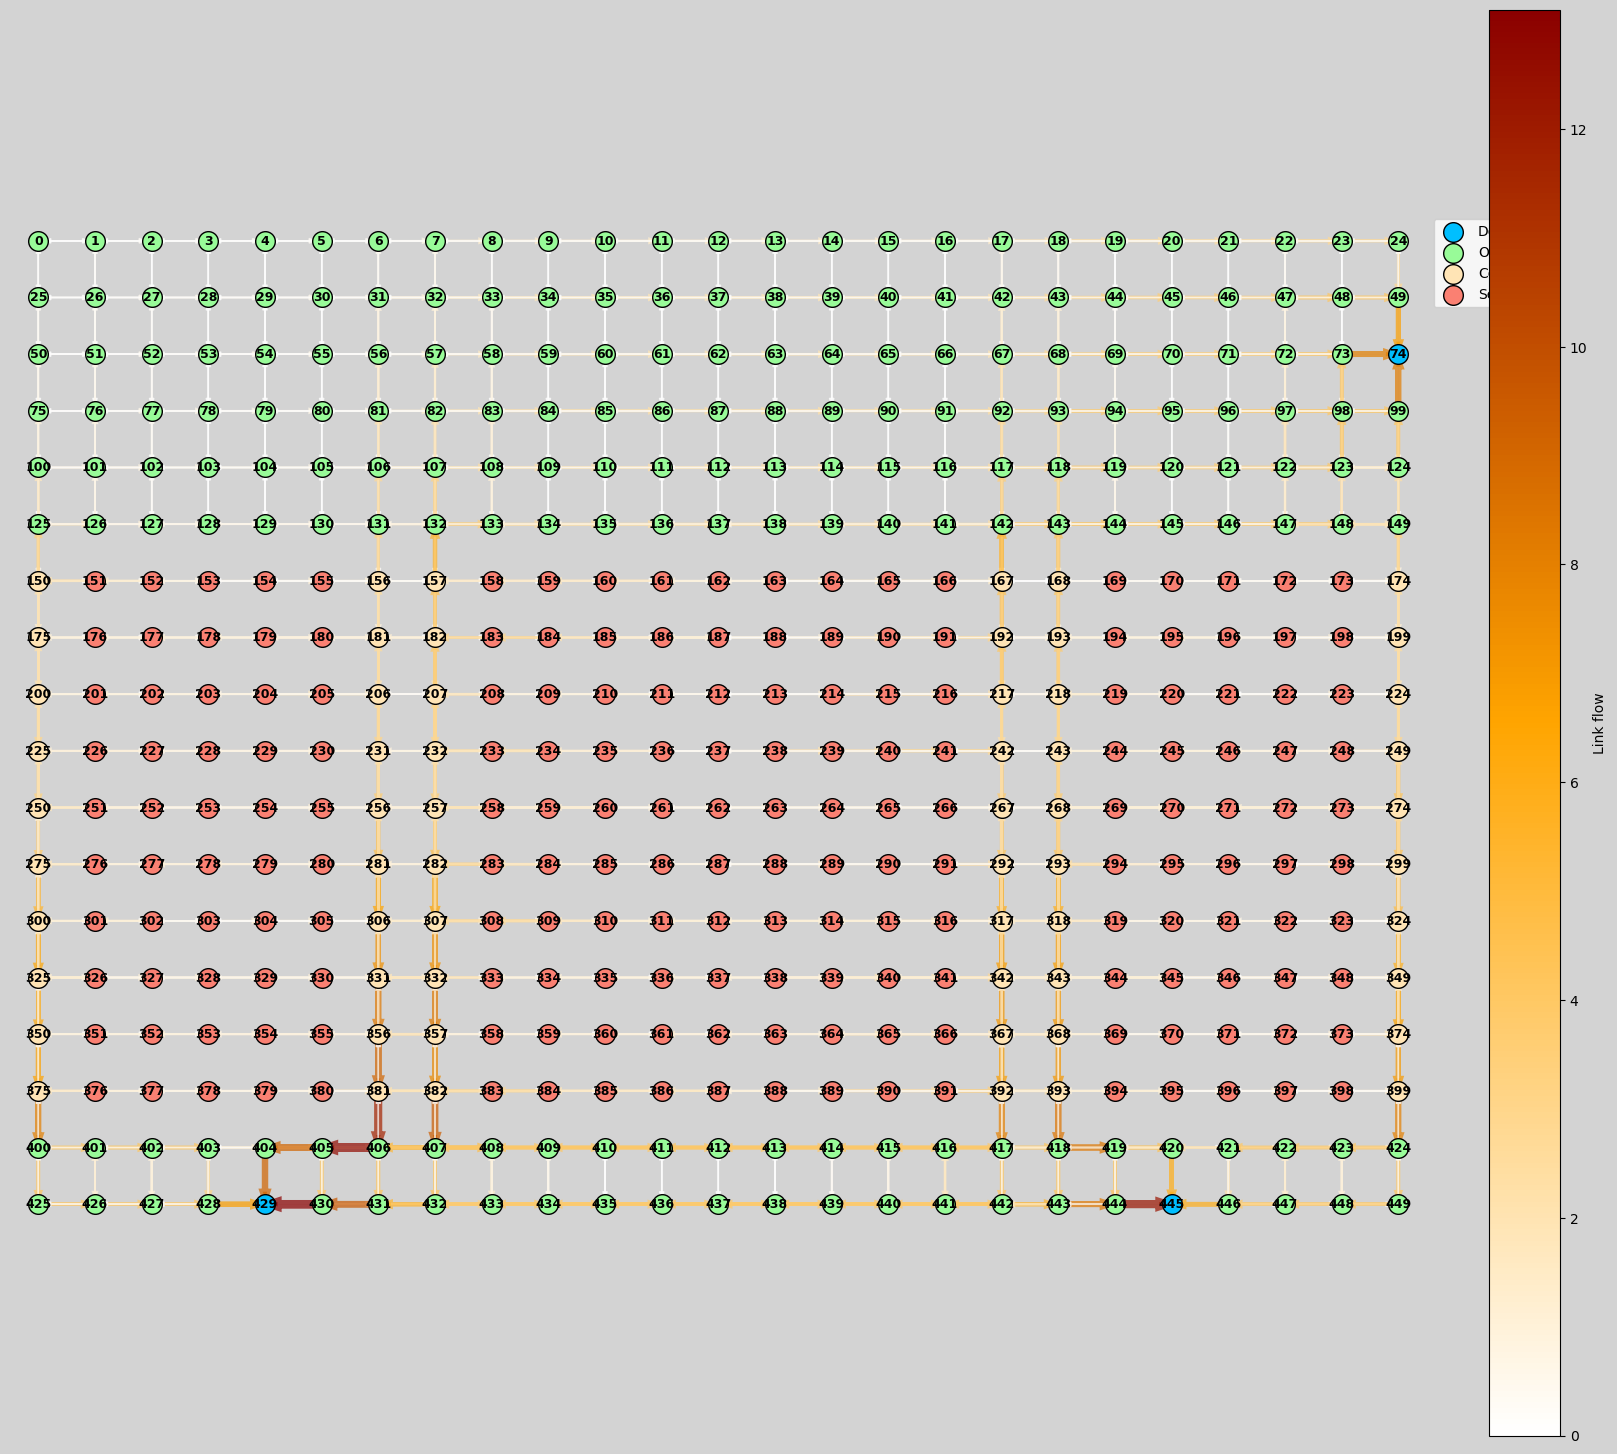

In [69]:
plot_network(df_nodes, df_links, idx_doors, X, Y, True, False, figsize=(20,20), x=x_star_ue_rand, name="image/CE1_UE.pdf")

#### System optimum "random"

In [72]:
max_iter = 5000
max_gap = 1e-4
max_gap_ls = 1e-2
link_cost_function = link_cost_function_so
objective_function = objective_function_so
alpha = 0.15
beta = 4

x_star_so_rand, gap_so_rand, obj_so_rand = FW(max_iter, max_gap, max_gap_ls, link_cost_function, objective_function, df_od_rand, df_links, df_nodes, alpha, beta)

Iteration : 500 / 5000
Iteration : 1000 / 5000
Iteration : 1500 / 5000
Iteration : 2000 / 5000
Iteration : 2500 / 5000
Iteration : 3000 / 5000
Iteration : 3500 / 5000
Iteration : 4000 / 5000
Iteration : 4500 / 5000
Iteration : 5000 / 5000


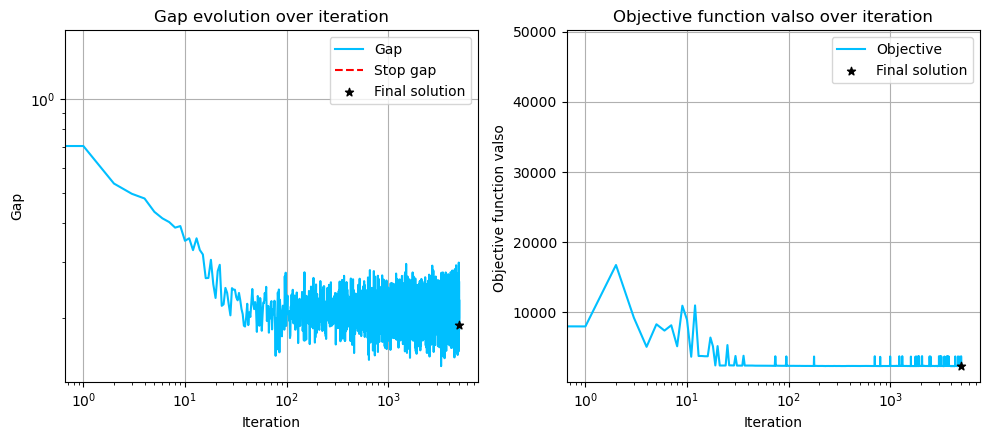

In [73]:
plt.figure(figsize=(10,4.5))

plt.subplot(1,2,1)
plt.loglog(np.arange(len(gap_so_rand)), gap_so_rand, color='Deepskyblue', label='Gap')
plt.hlines(1e-4, 0, 2*max_iter, color='red', linestyles='--', label='Stop gap')
plt.scatter(len(gap_so_rand)-1, gap_so_rand[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Gap")
plt.title("Gap evolution over iteration")

plt.legend()

plt.subplot(1,2,2)
plt.semilogx(np.arange(len(obj_so_rand)), obj_so_rand, color='Deepskyblue', label='Objective')
plt.scatter(len(obj_so_rand)-1, obj_so_rand[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Objective function valso ")
plt.title("Objective function valso over iteration")
plt.legend()

plt.tight_layout()
plt.show()

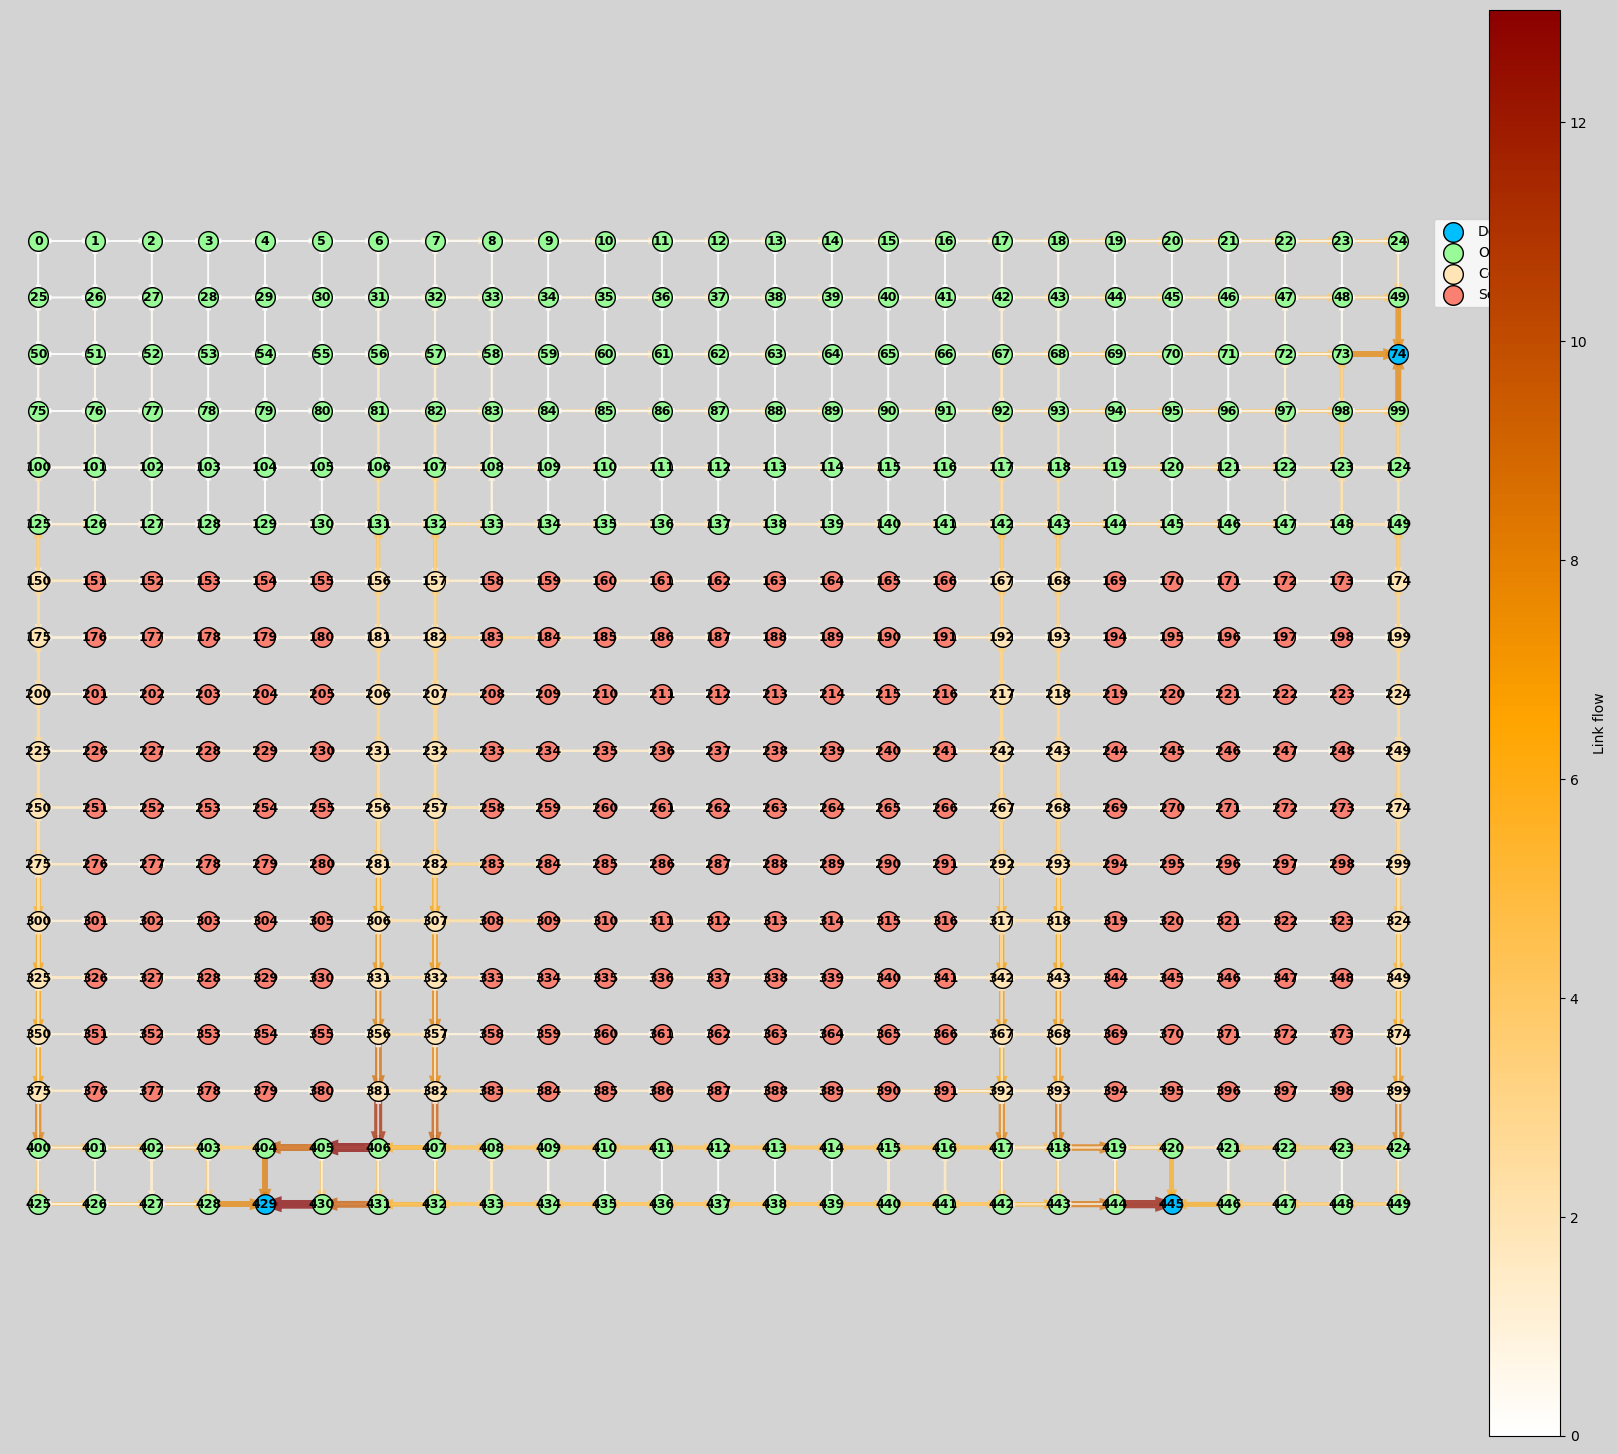

In [74]:
plot_network(df_nodes, df_links, idx_doors, X, Y, True, False, figsize=(20,20), x=x_star_so_rand, name="image/CE1_SO.pdf")

### Price of anarchy "random"

In [75]:
tt_ue_rand = objective_function_so(x=x_star_ue_rand, alpha=alpha, beta=beta, df_links=df_links)
tt_so_rand = objective_function_so(x=x_star_so_rand, alpha=alpha, beta=beta, df_links=df_links)

print('total travel time at UE "random": {:0.2f}'.format(tt_ue_rand))
print('total travel time at SO "random": {:0.2f}'.format(tt_so_rand))
print('PoA "random": {:0.2f}'.format(tt_ue_rand/tt_so_rand))

total travel time at UE "random": 14898.10
total travel time at SO "random": 14485.84
PoA "random": 1.03


### Closest demand generation

In [41]:
week = 14
df_od_clos, people_seat_clos = generate_demand(df_nodes, week, type_dystrib='closest')
df_od_clos

,od_id,origin,destination,demand
0,0,151,429,1.0
1,1,155,429,1.0
2,2,159,429,1.0
3,3,160,429,1.0
4,4,170,74,1.0
...,...,...,...,...
71,71,377,429,1.0
72,72,384,429,1.0
73,73,385,429,1.0
74,74,387,429,1.0


#### User equilibrium "closest"

In [42]:
max_iter = 5000
max_gap = 1e-4
max_gap_ls = 1e-2
link_cost_function = link_cost_function_ue
objective_function = objective_function_ue
alpha = 0.15
beta = 4

x_star_ue_clos, gap_ue_clos, obj_ue_clos = FW(max_iter, max_gap, max_gap_ls, link_cost_function, objective_function, df_od_clos, df_links, df_nodes, alpha, beta)

Iteration : 500 / 5000
Iteration : 1000 / 5000
Iteration : 1500 / 5000
Iteration : 2000 / 5000
Iteration : 2500 / 5000
Iteration : 3000 / 5000
Iteration : 3500 / 5000
Iteration : 4000 / 5000
Iteration : 4500 / 5000
Iteration : 5000 / 5000


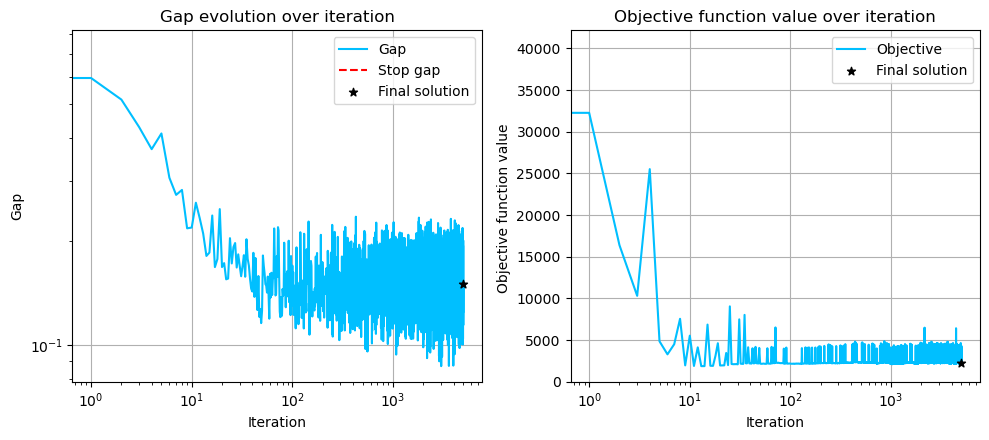

In [43]:
plt.figure(figsize=(10,4.5))

plt.subplot(1,2,1)
plt.loglog(np.arange(len(gap_ue_clos)), gap_ue_clos, color='Deepskyblue', label='Gap')
plt.hlines(1e-4, 0, 2*max_iter, color='red', linestyles='--', label='Stop gap')
plt.scatter(len(gap_ue_clos)-1, gap_ue_clos[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Gap")
plt.title("Gap evolution over iteration")

plt.legend()

plt.subplot(1,2,2)
plt.semilogx(np.arange(len(obj_ue_clos)), obj_ue_clos, color='Deepskyblue', label='Objective')
plt.scatter(len(obj_ue_clos)-1, obj_ue_clos[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Objective function value ")
plt.title("Objective function value over iteration")
plt.legend()

plt.tight_layout()
plt.show()

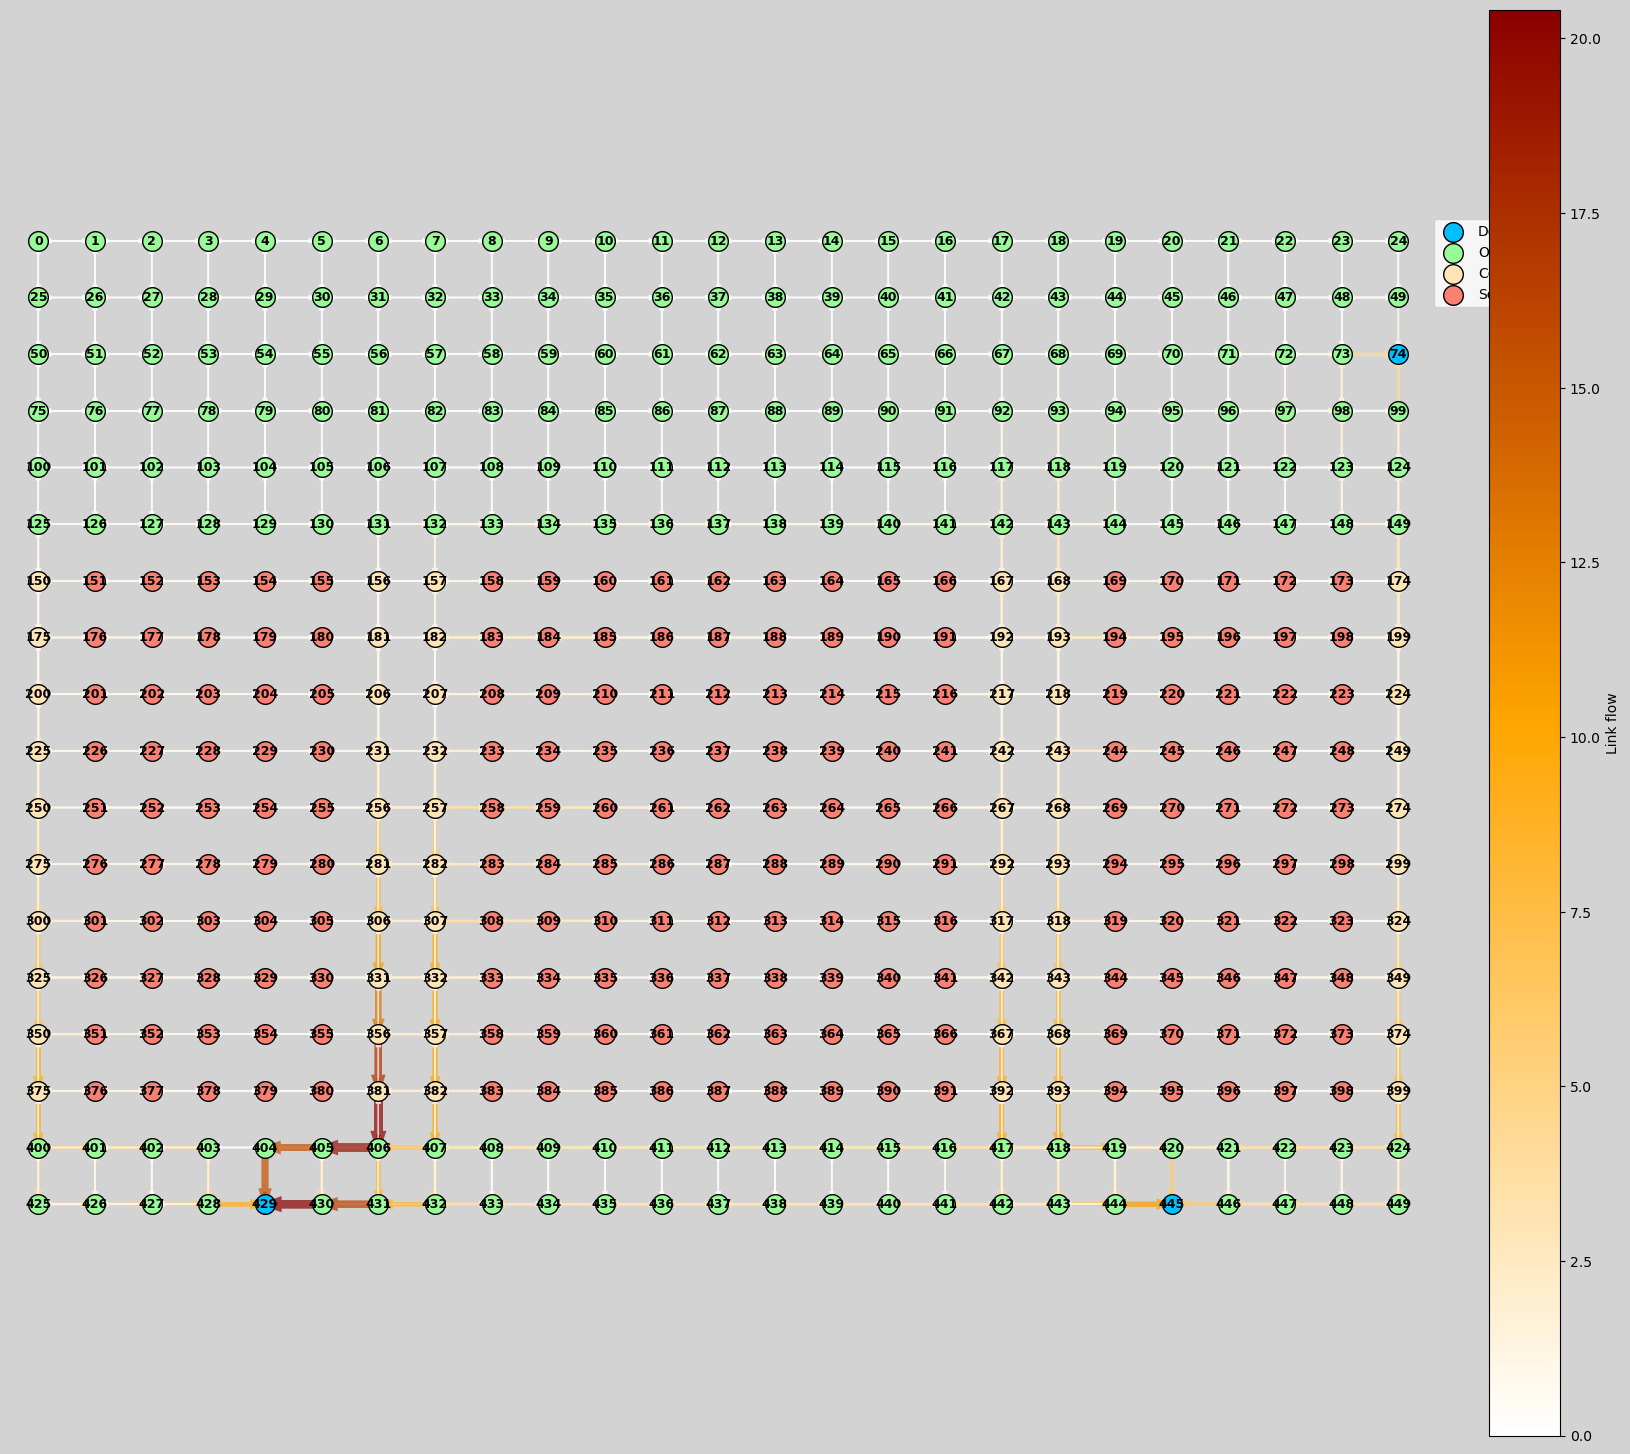

In [44]:
plot_network(df_nodes, df_links, idx_doors, X, Y, True, False, figsize=(20,20), x=x_star_ue_clos, name="image/CE1_UE.pdf")

### System optimum "closest"

In [48]:
max_iter = 5000
max_gap = 1e-4
max_gap_ls = 1e-2
link_cost_function = link_cost_function_so
objective_function = objective_function_so
alpha = 0.15
beta = 4

x_star_so_clos, gap_so_clos, obj_so_clos = FW(max_iter, max_gap, max_gap_ls, link_cost_function, objective_function, df_od_clos, df_links, df_nodes, alpha, beta)

Iteration : 500 / 5000
Iteration : 1000 / 5000
Iteration : 1500 / 5000
Iteration : 2000 / 5000
Iteration : 2500 / 5000
Iteration : 3000 / 5000
Iteration : 3500 / 5000
Iteration : 4000 / 5000
Iteration : 4500 / 5000
Iteration : 5000 / 5000


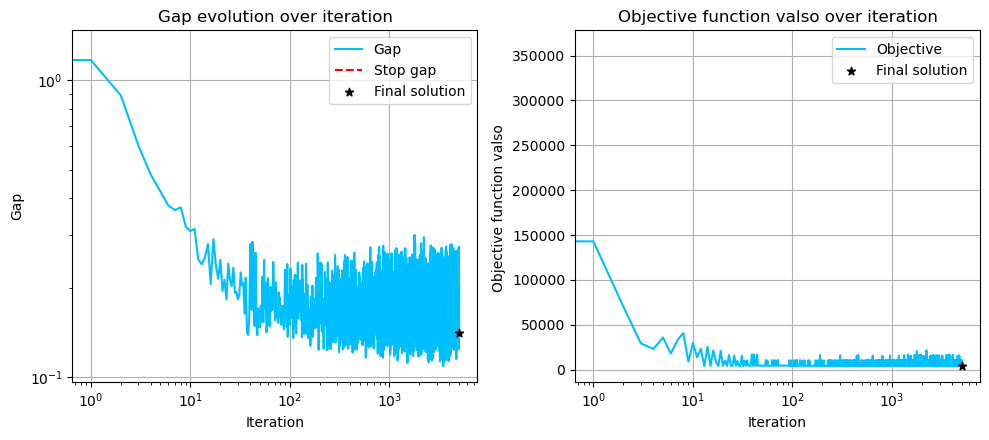

In [49]:
plt.figure(figsize=(10,4.5))

plt.subplot(1,2,1)
plt.loglog(np.arange(len(gap_so_clos)), gap_so_clos, color='Deepskyblue', label='Gap')
plt.hlines(1e-4, 0, 2*max_iter, color='red', linestyles='--', label='Stop gap')
plt.scatter(len(gap_so_clos)-1, gap_so_clos[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Gap")
plt.title("Gap evolution over iteration")

plt.legend()

plt.subplot(1,2,2)
plt.semilogx(np.arange(len(obj_so_clos)), obj_so_clos, color='Deepskyblue', label='Objective')
plt.scatter(len(obj_so_clos)-1, obj_so_clos[-1], marker='*', color='black', label='Final solution', zorder=3)
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Objective function valso ")
plt.title("Objective function valso over iteration")
plt.legend()

plt.tight_layout()
plt.show()

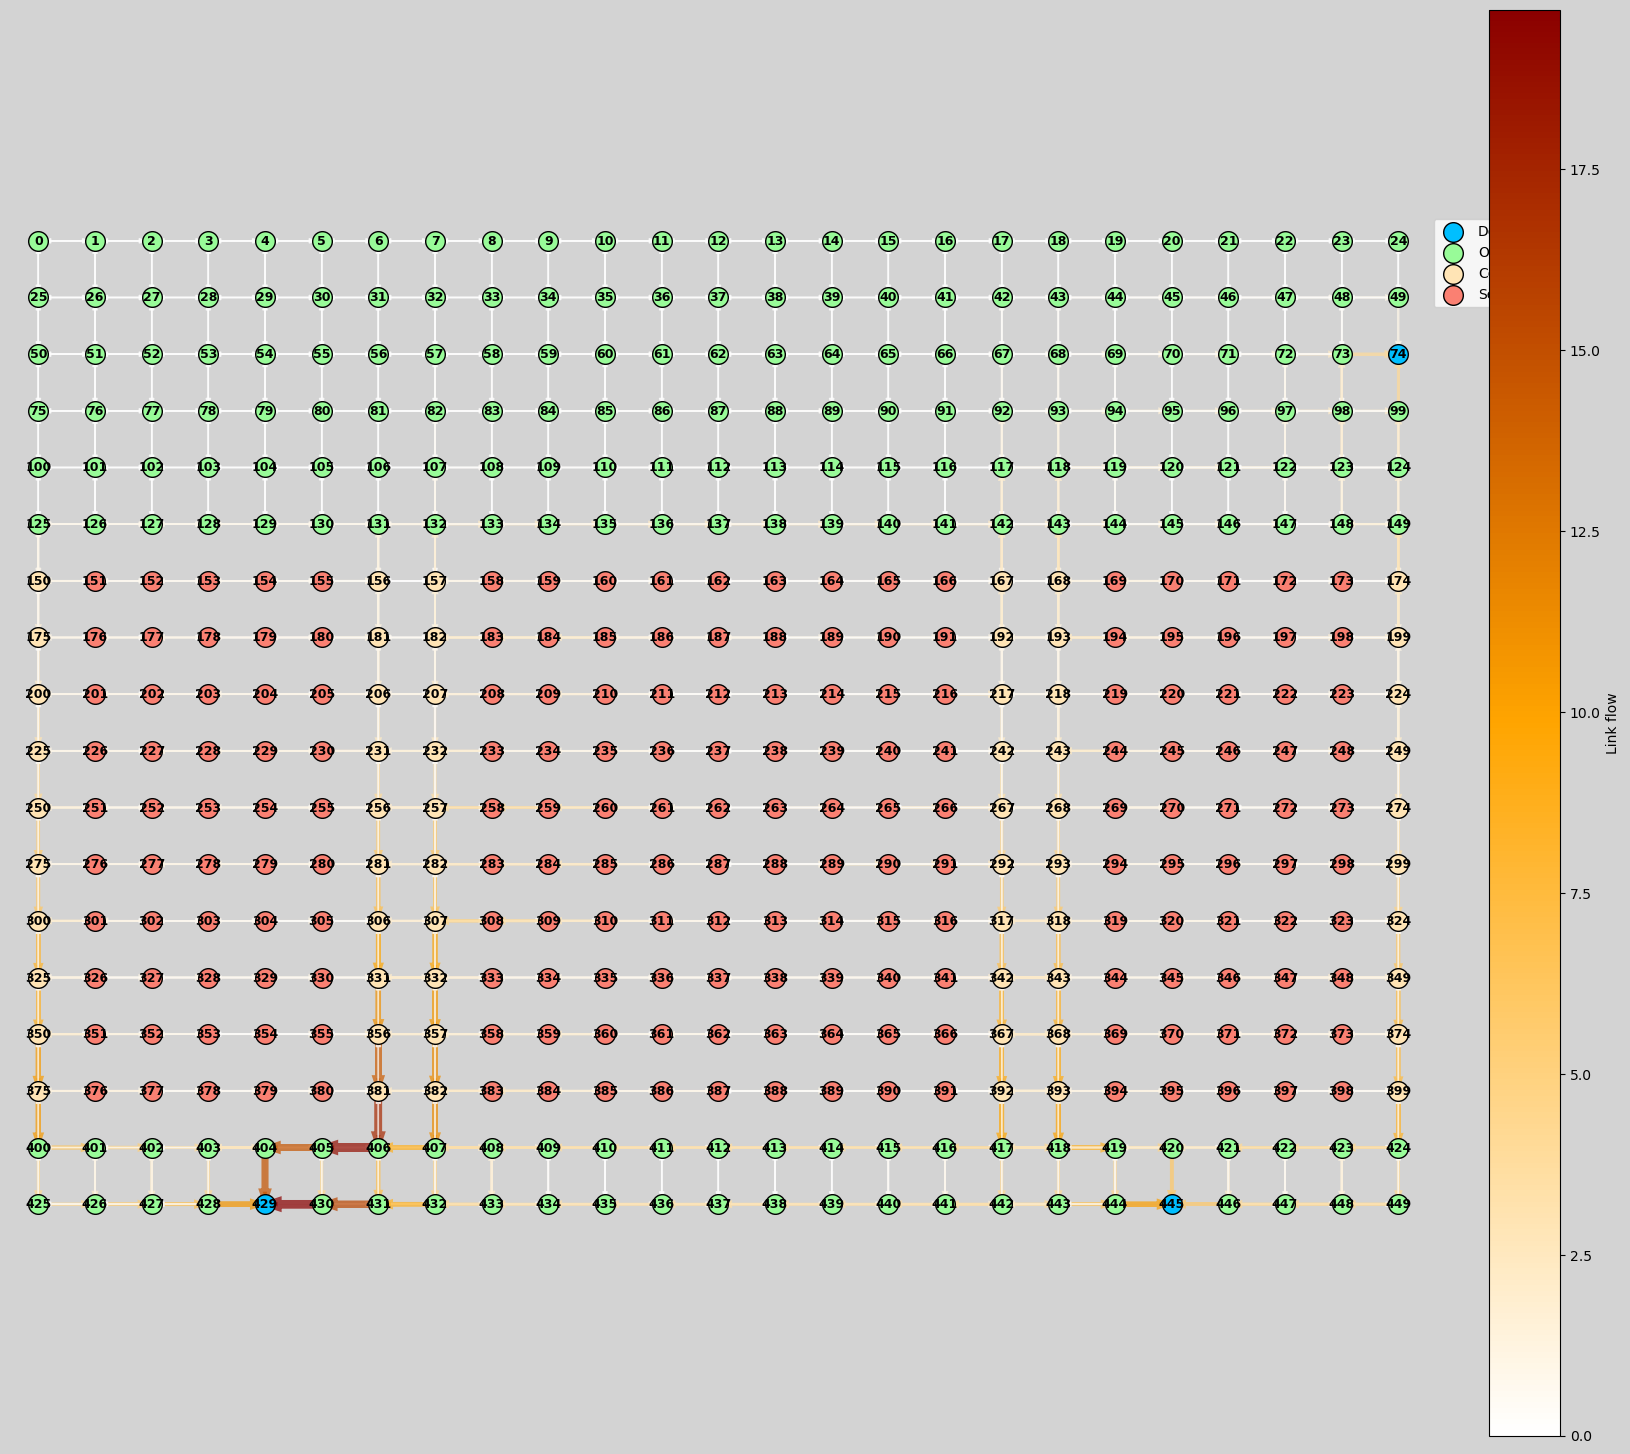

In [50]:
plot_network(df_nodes, df_links, idx_doors, X, Y, True, False, figsize=(20,20), x=x_star_so_clos, name="image/CE1_SO.pdf")

### Price of anarchy "closest"

In [51]:
tt_ue_clos = objective_function_so(x=x_star_ue_clos, alpha=alpha, beta=beta, df_links=df_links)
tt_so_clos = objective_function_so(x=x_star_so_clos, alpha=alpha, beta=beta, df_links=df_links)

print('total travel time at UE "closest": {:0.2f}'.format(tt_ue_clos))
print('total travel time at SO "closest": {:0.2f}'.format(tt_so_clos))
print('PoA "closest": {:0.2f}'.format(tt_ue_clos/tt_so_clos))

total travel time at UE "closest": 97444.78
total travel time at SO "closest": 58026.58
PoA "closest": 1.68


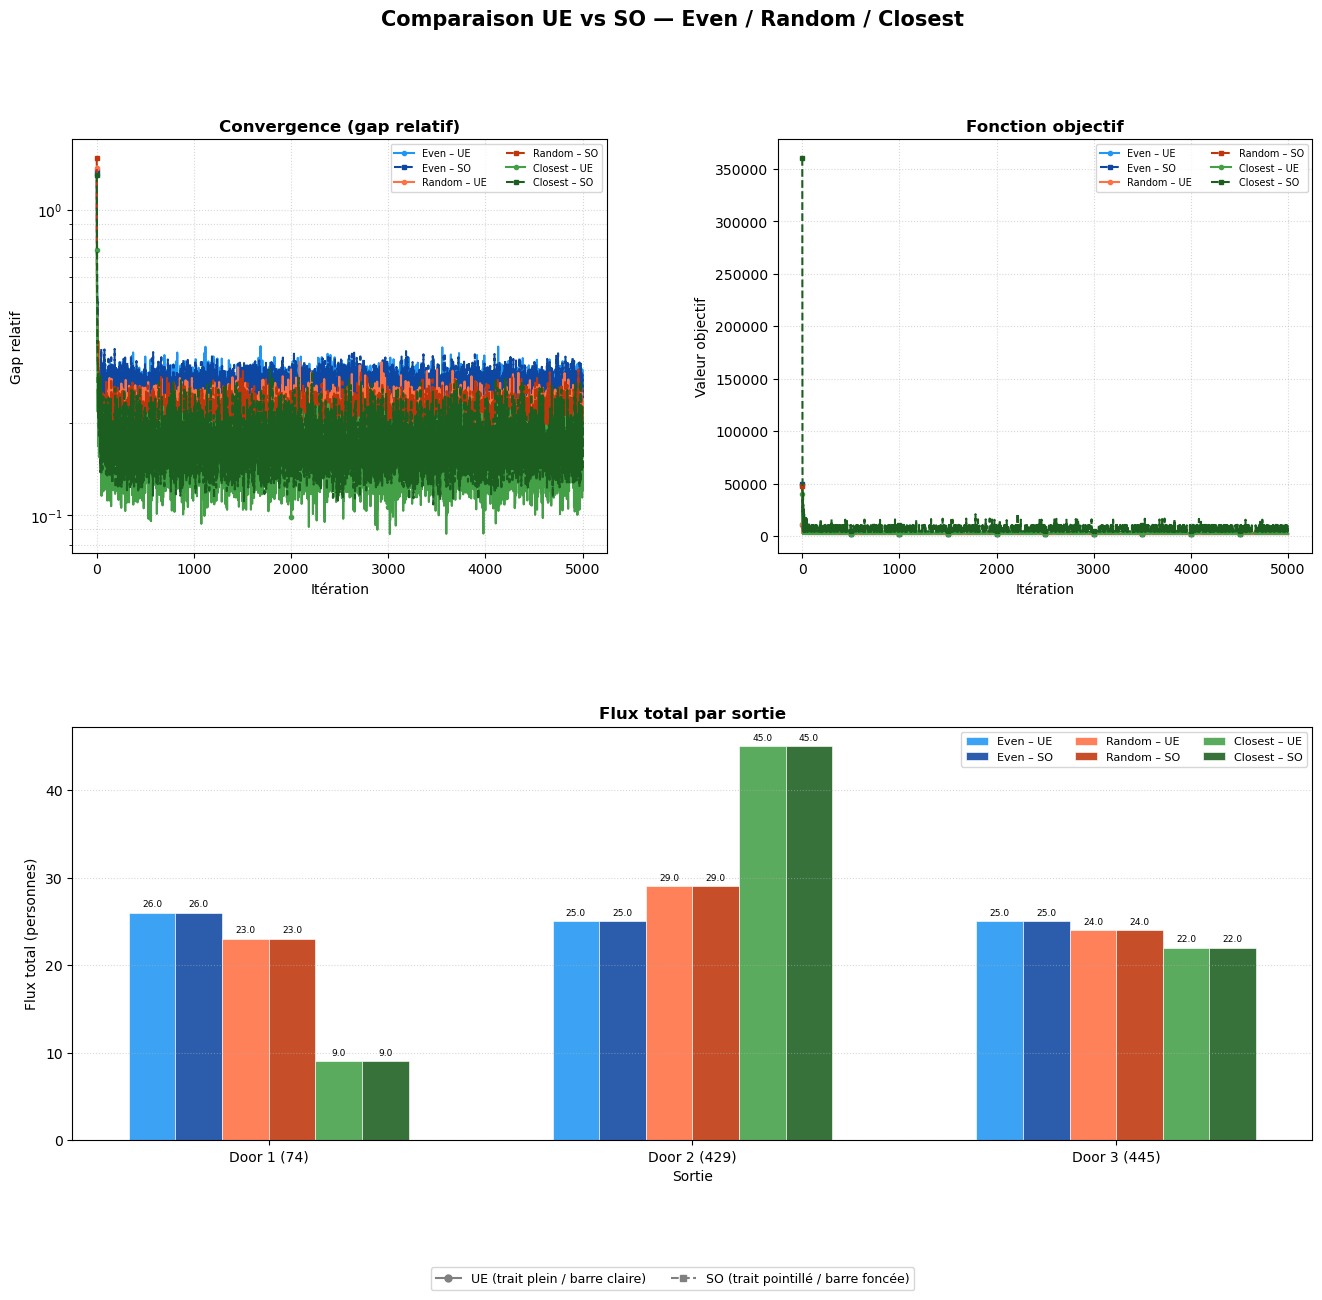

Figure sauvegardée : comparison_ue_so.png


In [76]:
door_names = ["Door 1 (74)", "Door 2 (429)", "Door 3 (445)"]

DOOR_LINKS = {
    name: df_links.index[df_links["end_node"] == door_id].tolist()
    for name, door_id in zip(door_names, idx_doors)
}

# ── DONNÉES PAR DISTRIBUTION ───────────────────────────────────────────────────
scenarios = {
    "Even": {
        "ue": {"x_star": x_star_ue,      "gap": gap_ue,      "obj": obj_ue},
        "so": {"x_star": x_star_so,      "gap": gap_so,      "obj": obj_so},
    },
    "Random": {
        "ue": {"x_star": x_star_ue_rand, "gap": gap_ue_rand, "obj": obj_ue_rand},
        "so": {"x_star": x_star_so_rand, "gap": gap_so_rand, "obj": obj_so_rand},
    },
    "Closest": {
        "ue": {"x_star": x_star_ue_clos, "gap": gap_ue_clos, "obj": obj_ue_clos},
        "so": {"x_star": x_star_so_clos, "gap": gap_so_clos, "obj": obj_so_clos},
    },
}

# ── PALETTE ────────────────────────────────────────────────────────────────────
COLORS = {
    "Even":    {"ue": "#2196F3", "so": "#0D47A1"},
    "Random":  {"ue": "#FF7043", "so": "#BF360C"},
    "Closest": {"ue": "#43A047", "so": "#1B5E20"},
}
LINE_STYLE = {"ue": "-",  "so": "--"}
MARKERS    = {"ue": "o",  "so": "s"}

# ── HELPER : flux total par porte ──────────────────────────────────────────────
def flux_par_porte(x_star):
    return [np.sum(x_star[idx]) for idx in DOOR_LINKS.values()]

# ── FIGURE ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 13))
fig.suptitle("Comparaison UE vs SO — Even / Random / Closest",
             fontsize=15, fontweight="bold", y=0.98)

gs      = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
ax_gap  = fig.add_subplot(gs[0, 0])
ax_obj  = fig.add_subplot(gs[0, 1])
ax_flux = fig.add_subplot(gs[1, :])

# ── 1. CONVERGENCE ─────────────────────────────────────────────────────────────
for dist, data in scenarios.items():
    for method in ("ue", "so"):
        gap   = data[method]["gap"]
        iters = np.arange(1, len(gap) + 1)
        ax_gap.plot(
            iters, gap,
            color=COLORS[dist][method],
            linestyle=LINE_STYLE[method],
            marker=MARKERS[method], markersize=3,
            markevery=max(1, len(gap) // 10),
            label=f"{dist} – {'UE' if method == 'ue' else 'SO'}",
        )

ax_gap.set_title("Convergence (gap relatif)", fontweight="bold")
ax_gap.set_xlabel("Itération")
ax_gap.set_ylabel("Gap relatif")
ax_gap.set_yscale("log")
ax_gap.legend(fontsize=7, ncol=2, loc="upper right")
ax_gap.grid(True, which="both", linestyle=":", alpha=0.5)

# ── 2. FONCTION OBJECTIF ───────────────────────────────────────────────────────
for dist, data in scenarios.items():
    for method in ("ue", "so"):
        obj   = data[method]["obj"]
        iters = np.arange(1, len(obj) + 1)
        ax_obj.plot(
            iters, obj,
            color=COLORS[dist][method],
            linestyle=LINE_STYLE[method],
            marker=MARKERS[method], markersize=3,
            markevery=max(1, len(obj) // 10),
            label=f"{dist} – {'UE' if method == 'ue' else 'SO'}",
        )

ax_obj.set_title("Fonction objectif", fontweight="bold")
ax_obj.set_xlabel("Itération")
ax_obj.set_ylabel("Valeur objectif")
ax_obj.legend(fontsize=7, ncol=2, loc="upper right")
ax_obj.grid(True, linestyle=":", alpha=0.5)

# ── 3. FLUX PAR SORTIE ─────────────────────────────────────────────────────────
door_labels = list(DOOR_LINKS.keys())
n_doors     = len(door_labels)
n_groups    = len(scenarios) * 2      # 3 distributions × 2 méthodes = 6 barres
bar_width   = 0.11
x_base      = np.arange(n_doors)

bar_idx = 0
for dist, data in scenarios.items():
    for method in ("ue", "so"):
        fluxes  = flux_par_porte(data[method]["x_star"])
        offsets = x_base + (bar_idx - n_groups / 2 + 0.5) * bar_width
        label   = f"{dist} – {'UE' if method == 'ue' else 'SO'}"

        bars = ax_flux.bar(
            offsets, fluxes,
            width=bar_width,
            color=COLORS[dist][method],
            label=label,
            edgecolor="white", linewidth=0.5,
            alpha=0.88,
        )
        for bar, val in zip(bars, fluxes):
            ax_flux.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.1f}",
                ha="center", va="bottom", fontsize=6.5,
            )
        bar_idx += 1

ax_flux.set_title("Flux total par sortie", fontweight="bold")
ax_flux.set_xlabel("Sortie")
ax_flux.set_ylabel("Flux total (personnes)")
ax_flux.set_xticks(x_base)
ax_flux.set_xticklabels(door_labels)
ax_flux.legend(fontsize=8, ncol=3, loc="upper right")
ax_flux.grid(axis="y", linestyle=":", alpha=0.5)

# ── LÉGENDE COMMUNE (UE vs SO) ─────────────────────────────────────────────────
legend_style = [
    Line2D([0], [0], color="gray", linestyle="-",  marker="o", markersize=5, label="UE (trait plein / barre claire)"),
    Line2D([0], [0], color="gray", linestyle="--", marker="s", markersize=5, label="SO (trait pointillé / barre foncée)"),
]
fig.legend(handles=legend_style, loc="lower center", ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), frameon=True)

plt.savefig("comparison_ue_so.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : comparison_ue_so.png")

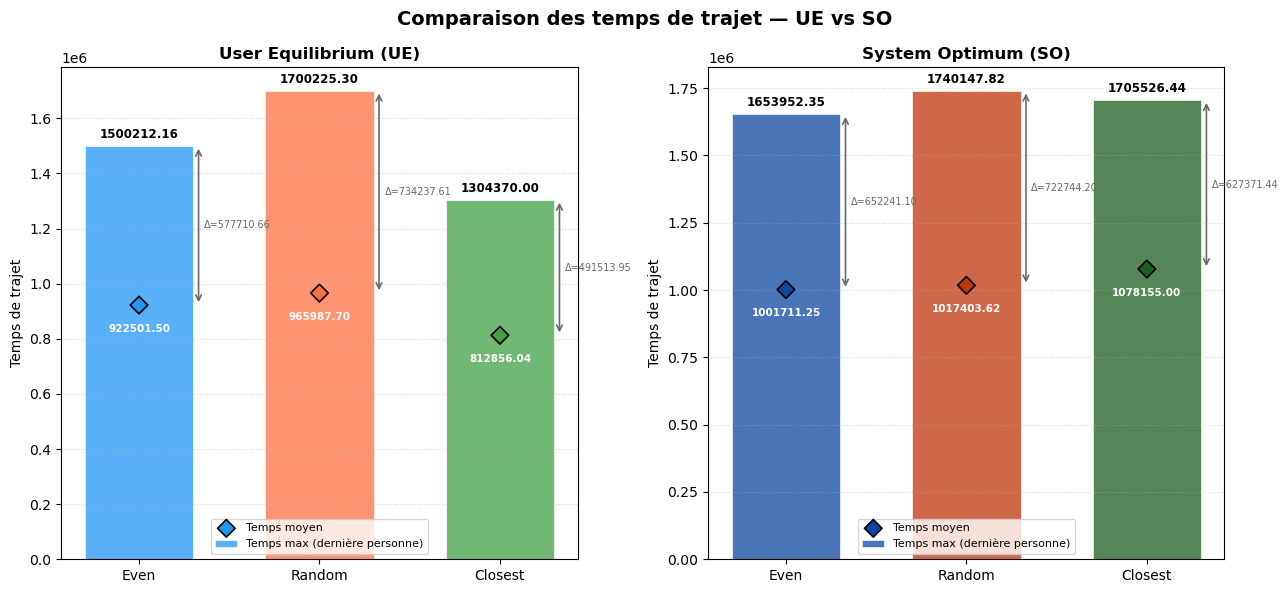

Figure sauvegardée : travel_times_comparison.png


In [77]:
scenarios = {
    "Even": {
        "ue": compute_travel_times(x_star_ue,      df_od, df_nodes, df_links, link_cost_function_ue, alpha, beta),
        "so": compute_travel_times(x_star_so,      df_od, df_nodes, df_links, link_cost_function_so, alpha, beta),
    },
    "Random": {
        "ue": compute_travel_times(x_star_ue_rand, df_od_rand, df_nodes, df_links, link_cost_function_ue, alpha, beta),
        "so": compute_travel_times(x_star_so_rand, df_od_rand, df_nodes, df_links, link_cost_function_so, alpha, beta),
    },
    "Closest": {
        "ue": compute_travel_times(x_star_ue_clos, df_od_clos, df_nodes, df_links, link_cost_function_ue, alpha, beta),
        "so": compute_travel_times(x_star_so_clos, df_od_clos, df_nodes, df_links, link_cost_function_so, alpha, beta),
    },
}

# ── PALETTE ────────────────────────────────────────────────────────────────────
COLORS = {
    "Even":    {"ue": "#2196F3", "so": "#0D47A1"},
    "Random":  {"ue": "#FF7043", "so": "#BF360C"},
    "Closest": {"ue": "#43A047", "so": "#1B5E20"},
}

dist_labels   = list(scenarios.keys())   # Even, Random, Closest
method_labels = ["UE", "SO"]
n_dist        = len(dist_labels)
bar_width     = 0.30
x_base        = np.arange(n_dist)

# ── FIGURE ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)
fig.suptitle("Comparaison des temps de trajet — UE vs SO", fontsize=14, fontweight="bold")

for ax, method in zip(axes, ("ue", "so")):
    t_max  = [scenarios[d][method].max()  for d in dist_labels]
    t_mean = [scenarios[d][method].mean() for d in dist_labels]
    colors = [COLORS[d][method] for d in dist_labels]

    # Barres : temps maximum
    bars = ax.bar(x_base, t_max, width=bar_width * 2, color=colors,
                  alpha=0.75, edgecolor="white", linewidth=0.6,
                  label="Temps max (dernière personne)")

    # Marqueurs : temps moyen superposé
    ax.scatter(x_base, t_mean, color=colors, edgecolors="black",
               s=80, zorder=5, marker="D", linewidths=1.2,
               label="Temps moyen")

    # Annotations valeurs
    for i, (vmax, vmean) in enumerate(zip(t_max, t_mean)):
        ax.text(i, vmax + 0.01 * max(t_max), f"{vmax:.2f}",
                ha="center", va="bottom", fontsize=8.5, fontweight="bold")
        ax.text(i, vmean - 0.04 * max(t_max), f"{vmean:.2f}",
                ha="center", va="top", fontsize=7.5, color="white", fontweight="bold")

    ax.set_title(f"{'User Equilibrium (UE)' if method == 'ue' else 'System Optimum (SO)'}",
                 fontweight="bold")
    ax.set_xticks(x_base)
    ax.set_xticklabels(dist_labels, fontsize=10)
    ax.set_ylabel("Temps de trajet")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.legend(fontsize=8)

    # Écart max-moyen annoté discètement
    for i, (vmax, vmean) in enumerate(zip(t_max, t_mean)):
        ax.annotate("", xy=(i + bar_width * 1.1, vmean),
                    xytext=(i + bar_width * 1.1, vmax),
                    arrowprops=dict(arrowstyle="<->", color="dimgray", lw=1.2))
        ax.text(i + bar_width * 1.2, (vmax + vmean) / 2,
                f"Δ={vmax - vmean:.2f}", fontsize=7, color="dimgray", va="center")

plt.tight_layout()
plt.savefig("travel_times_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : travel_times_comparison.png")
